In [856]:
# Cell 1: Imports
import numpy as np
import scipy.io
import scipy.signal
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter
from scipy.spatial.distance import cdist
from scipy.linalg import eigh,eig
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
from sklearn.cross_decomposition import CCA
from scipy.signal import butter, filtfilt, welch, find_peaks, resample
from sklearn.decomposition import FastICA
from scipy.signal import periodogram
from scipy.signal import medfilt
from scipy.signal import butter, filtfilt
from numpy.lib.stride_tricks import sliding_window_view
exec(open("Functions.py").read())
from sklearn.metrics import confusion_matrix
from scipy.signal import find_peaks
from sklearn.metrics import auc

In [857]:
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Times New Roman"
plt.rcParams["mathtext.it"] = "Times New Roman:italic"
plt.rcParams["mathtext.bf"] = "Times New Roman:bold"

In [858]:
import numpy as np
from scipy.signal import find_peaks
from sklearn.metrics import auc
import mir_eval
import numpy as np

def collapse_windows_to_centers(binary_vec, mode="center"):
    """
    mode:
      "center"  → midpoint of the window
      "left"    → first index
      "right"   → last index
    """
    binary_vec = np.asarray(binary_vec, dtype=int)
    out = np.zeros_like(binary_vec)

    # find rising and falling edges
    padded = np.pad(binary_vec, (1, 1))
    diff = np.diff(padded)

    starts = np.where(diff == 1)[0]
    ends   = np.where(diff == -1)[0] - 1

    for s, e in zip(starts, ends):
        if mode == "center":
            idx = (s + e) // 2
        elif mode == "left":
            idx = s
        elif mode == "right":
            idx = e
        else:
            raise ValueError("Unknown mode")

        out[idx] = 1

    return out


def add_tolerance(binary_vec, window):
    """
    window = number of samples to extend on EACH side
    """
    kernel = np.ones(2 * window + 1, dtype=int)
    return (np.convolve(binary_vec, kernel, mode='same') > 0).astype(int)
    
def coverage_PR_AUC(score_signal, gt, fs, thresholds=None, tolerance_window=1, check_sign=True):
    """
    Compute event-level PR-AUC for a continuous score_signal.
    
    Parameters
    ----------
    score_signal : ndarray
        Continuous score vector (mapped to original ECG length).
    gt : list or ndarray
        Ground truth event times in seconds.
    fs : float
        Sampling rate of the score_signal (samples/sec).
    thresholds : array-like, optional
        Thresholds to sweep over. If None, 200 linearly spaced thresholds between min and max.
    tolerance_sec : float
        Temporal tolerance for matching events (seconds).
        
    Returns
    -------
    precision_arr, recall_arr, pr_auc : ndarray, ndarray, float
    """
    #Check sign alignment for eigenvectors scores:
    if check_sign:
        if abs(score_signal.min()) > abs(score_signal.max()):
            score_signal = -score_signal
    

    if thresholds is None:
        # pos_sig = score_signal[score_signal>=0]
        # neg_sig = score_signal[score_signal<=0]
        # l_b = np.min(score_signal)+0.1*np.std(neg_sig)
        # u_b = np.max(score_signal)-0.1*np.std(pos_sig)
        thresholds = np.linspace(np.min(score_signal), np.max(score_signal)-1e-5, 200)
    
    precision_arr = []
    recall_arr = []

    for thr in thresholds:
        # detect peaks above threshold
        est_s = score_signal>thr  # distance=int(0.2*fs) optional refractory period
        
        # compute confusion with gt:
        cm = confusion_matrix(gt, est_s)
        # Unpack the values
        TN, _, _, _ = cm.ravel()

        #compute tolerance-gt and confusion:
        tol_gt = add_tolerance(gt, tolerance_window)
        cm = confusion_matrix(tol_gt, est_s)
        # Unpack the values
        _, FP, _, TP = cm.ravel()

        #compute tolerance-signal and confusion for FN:
        # if gt is suppose to detect the estimation with a window - FP is actually FN of the estimation...
        tol_sig = add_tolerance(est_s, tolerance_window)
        cm = confusion_matrix(tol_sig, gt)
        # Unpack the values
        _, FN, _, _ = cm.ravel()

        #compute precision and recall:
        prec = TP/(TP+FP)
        rec = TP/(TP+FN)
        
        precision_arr.append(prec)
        recall_arr.append(rec)
    
    precision_arr = np.array(precision_arr)
    recall_arr = np.array(recall_arr)
    
    # compute PR-AUC using trapezoidal integration
    # sort by recall ascending for correct integration
    sorted_idx = np.argsort(recall_arr)
    pr_auc = auc(recall_arr[sorted_idx], precision_arr[sorted_idx])
    
    return precision_arr, recall_arr, pr_auc


In [859]:
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score

def evaluate_vec_binary(s, y, return_pr_auc=False):
    """
    Evaluate a continuous vector against a binary ground-truth vector.

    Parameters
    ----------
    s : array-like, shape (n,)
        Continuous scores.
    y : array-like, shape (n,)
        Binary ground-truth labels (0/1).
    return_pr_auc : bool, optional
        If True, also return PR-AUC.

    Returns
    -------
    auc : float
        ROC-AUC score, corrected for ICA sign ambiguity.
    pr_auc : float (optional)
        Precision-Recall AUC (if requested).
    """

    s = np.asarray(s).ravel()
    y = np.asarray(y).ravel()

    # --- ROC-AUC with sign ambiguity ---
    auc_pos = roc_auc_score(y, s)
    auc_neg = roc_auc_score(y, -s)
    auc = max(auc_pos, auc_neg)

    if return_pr_auc:
        pr_pos = average_precision_score(y, s)
        pr_neg = average_precision_score(y, -s)
        pr_auc = max(pr_pos, pr_neg)
        return auc, pr_auc

    return auc


In [860]:
def highpass_filter(sig, fs=1000, cutoff=0.5, order=5):
    b, a = butter(order, cutoff / (0.5 * fs), btype='highpass')
    return filtfilt(b, a, sig)


# def remove_baseline_median(sig, fs=1000, window_ms=500):
#     w = int(fs * window_ms / 1000)
#     baseline = medfilt(sig, kernel_size=w if w % 2 else w+1)
#     return sig - baseline

def remove_baseline_median(sig, window_size=101):
    baseline = medfilt(sig, kernel_size=window_size)
    return sig - baseline
    
def lowpass_filter(sig, fs=1000, cutoff=100, order=5):
    b, a = butter(order, cutoff / (0.5 * fs), btype='lowpass')
    return filtfilt(b, a, sig)


def preprocess_ecg(sig, fs=1000):
    sig = lowpass_filter(sig, fs, cutoff=100)          # step 1: low-pass <100 Hz
    sig = remove_baseline_median(sig, window_size=101) # step 2: remove trend
    sig = (sig - np.mean(sig)) / np.std(sig)           # step 3: normalize
    return sig
    
# --- helper: convert detection indices in subsampled-lag rows -> original sample index ---
def subsampled_row_to_orig_sample(det_sub):
    # det_sub: array-like of indices in the subsampled lag matrix (0..n_rows_sub-1)
    return np.asarray(det_sub, dtype=int) * jump


In [861]:
def window_vector_to_signal(v, signal_length, lag, jump, fill_value=0.0):
    """
    Map window-level values to a signal-length vector by placing
    each value at the center of its window.

    Parameters
    ----------
    v : array-like, shape (n_windows,)
        Window-level values.
    signal_length : int
        Length of original ECG signal.
    lag : int
        Length L of each window.
    window_start_indices : array-like, shape (n_windows,)
        Start index t_k of each window.
    fill_value : float, optional
        Value for non-window-center samples (default: 0).

    Returns
    -------
    s : ndarray, shape (signal_length,)
        Signal-level vector with window values at centers.
    """
    window_start_indices = np.arange(0, signal_length - lag, jump)
    s = np.full(signal_length, fill_value, dtype=float)
    half = lag // 2

    for k, val in enumerate(v):
        center = window_start_indices[k] + half
        if 0 <= center < signal_length:
            s[center] = val

    return s


In [862]:
def evaluate_detections(detections_samples, reference_samples, fs=1000, tol_ms=50):
    """
    Evaluate detection timing with tolerance window ±tol_ms.
    Inputs:
      detections_samples : 1D array-like (sample indices) of detected QRS times (sorted or unsorted)
      reference_samples  : 1D array-like (sample indices) of reference QRS times (sorted or unsorted)
      fs                 : sampling frequency in Hz (default 1000)
      tol_ms             : tolerance in milliseconds (default 50 ms)
    Returns:
      dict with TP, FP, FN, precision, recall, f1, mean_abs_error_ms,
           matched_pairs (list of (det_sample, ref_sample))
    """
    det = np.asarray(detections_samples, dtype=int)
    ref = np.asarray(reference_samples, dtype=int)
    if det.size == 0 and ref.size == 0:
        return {'TP':0,'FP':0,'FN':0,'precision':1.0,'recall':1.0,'f1':1.0,'mean_abs_error_ms':0.0,'matched_pairs':[]}
    det.sort()
    ref.sort()
    tol_samples = int(round(tol_ms ))

    i = 0  # index for det
    j = 0  # index for ref
    matched = []
    while i < len(det) and j < len(ref):
        d = det[i]
        r = ref[j]
        diff = d - r
        if abs(diff) <= tol_samples:
            # match them
            matched.append((d, r))
            i += 1
            j += 1
        else:
            # no match: advance the earlier time
            if d < r:
                # detection earlier than reference (and not within tol) -> false positive
                i += 1
            else:
                # reference earlier than detection (not matched) -> missed (false negative)
                j += 1

    TP = len(matched)
    FP = len(det) - TP
    FN = len(ref) - TP
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    if TP > 0:
        abs_errors_ms = [abs(d - r) / fs * 1000.0 for d, r in matched]
        mean_abs_error_ms = float(np.mean(abs_errors_ms))
    else:
        mean_abs_error_ms = float('nan')

    return {
        'TP': TP, 'FP': FP, 'FN': FN,
        'precision': precision, 'recall': recall, 'f1': f1,
        'mean_abs_error_ms': mean_abs_error_ms
        # 'matched_pairs': matched
    }


In [863]:

def evaluate_detections(detections_samples, reference_samples, fs=1000, tol_ms=50):
    """
    Evaluate detection timing with tolerance window ±tol_ms.
    Inputs:
      detections_samples : 1D array-like (sample indices) of detected QRS times (sorted or unsorted)
      reference_samples  : 1D array-like (sample indices) of reference QRS times (sorted or unsorted)
      fs                 : sampling frequency in Hz (default 1000)
      tol_ms             : tolerance in milliseconds (default 50 ms)
    Returns:
      dict with TP, FP, FN, precision, recall, f1, mean_abs_error_ms,
           matched_pairs (list of (det_sample, ref_sample))
    """
    det = np.asarray(detections_samples, dtype=int)
    ref = np.asarray(reference_samples, dtype=int)
    if det.size == 0 and ref.size == 0:
        return {'TP':0,'FP':0,'FN':0,'precision':1.0,'recall':1.0,'f1':1.0,'mean_abs_error_ms':0.0,'matched_pairs':[]}
    det.sort()
    ref.sort()
    tol_samples = int(round(tol_ms ))

    i = 0  # index for det
    j = 0  # index for ref
    matched = []
    while i < len(det) and j < len(ref):
        d = det[i]
        r = ref[j]
        diff = d - r
        if abs(diff) <= tol_samples:
            # match them
            matched.append((d, r))
            i += 1
            j += 1
        else:
            # no match: advance the earlier time
            if d < r:
                # detection earlier than reference (and not within tol) -> false positive
                i += 1
            else:
                # reference earlier than detection (not matched) -> missed (false negative)
                j += 1
    
    
    TP = len(matched)
    FP = len(det) - TP
    FN = len(ref) - TP
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    total_samples = max(det.max() if det.size > 0 else 0,
                    ref.max() if ref.size > 0 else 0) + 1  # +1 if indices start at 0
    TN = total_samples - TP - FP - FN
    TNR = TN / (TN + FP) if (TN + FP) > 0 else np.nan
    balanced_accuracy = 0.5 * (recall + TNR)

    if TP > 0:
        abs_errors_ms = [abs(d - r) / fs * 1000.0 for d, r in matched]
        mean_abs_error_ms = float(np.mean(abs_errors_ms))
    else:
        mean_abs_error_ms = float('nan')

    # RR intervals RMSD
    if len(matched) > 1:
        rr_det_ms = np.diff([d for d, r in matched]) / fs * 1000
        rr_ref_ms = np.diff([r for d, r in matched]) / fs * 1000
        rmsd = float(np.sqrt(np.mean((rr_det_ms - rr_ref_ms)**2)))
    else:
        rmsd = float('nan')
        

    return {
        'TP': TP, 'FP': FP, 'FN': FN,
        'precision': precision, 'recall': recall, 'f1': f1,
        'balanced_accuracy': balanced_accuracy,
        'RMSD': rmsd,
        'mean_abs_error_ms': mean_abs_error_ms
        # 'matched_pairs': matched
    }


In [864]:
# Cell 2: Load and preprocess ECG signals
fs = 250

mat_f = scipy.io.loadmat('fECG.mat')
mat_m = scipy.io.loadmat('mECG.mat')
fECG = mat_f['fECG']
mECG = mat_m['mECG']

# Remove mean and normalize
fECG = (fECG - np.mean(fECG, axis=0)) / (0.5 * np.max(fECG))
mECG = (mECG - np.mean(mECG, axis=0)) / (0.5 * np.max(mECG))

# 60Hz notch filter
notch_freq = 60
Q = 30.0  # quality factor
b, a = scipy.signal.iirnotch(notch_freq, Q, fs)

fECG[:, 1] = scipy.signal.filtfilt(b, a, fECG[:, 1] - median_filter(fECG[:, 1], 100))
fECG[:, 2] = scipy.signal.filtfilt(b, a, fECG[:, 2] - median_filter(fECG[:, 2], 100))
mECG[:, 2] = scipy.signal.filtfilt(b, a, mECG[:, 2] - median_filter(mECG[:, 2], 100))

fECG[:, 1] = fECG[:, 1]/ (0.5 * np.max(fECG[:, 1]))
fECG[:, 2] = fECG[:, 2]/ (0.5 * np.max(fECG[:, 2]))
mECG[:, 2] = mECG[:, 2]/ (0.5 * np.max(mECG[:, 2]))


In [865]:
# Cell 3: Upsample and construct synthetic ta-ECG signals
fs = 1000  # New sampling rate
len_sig = 40000
sig_range = np.arange(len_sig)
t = np.arange(len_sig) / fs

mECGrs = resample(mECG[:, 2], 4 * len(mECG))
fECGrs1 = resample(fECG[:, 1], 2 * len(fECG))
fECGrs2 = resample(fECG[:, 2], 2 * len(fECG))

sig1 = 2* mECGrs[sig_range] - fECGrs1[sig_range]
sig2 = mECGrs[sig_range] - 0.5 * fECGrs2[sig_range]


# Ground truth of fECG beat locations and mECG beat locations:
fECGgt = fECGrs2[sig_range]
fECGgt = fECGgt>1
f_qrs = np.where(fECGgt)[0]

mECGgt = mECGrs[sig_range]
mECGgt = mECGgt>1


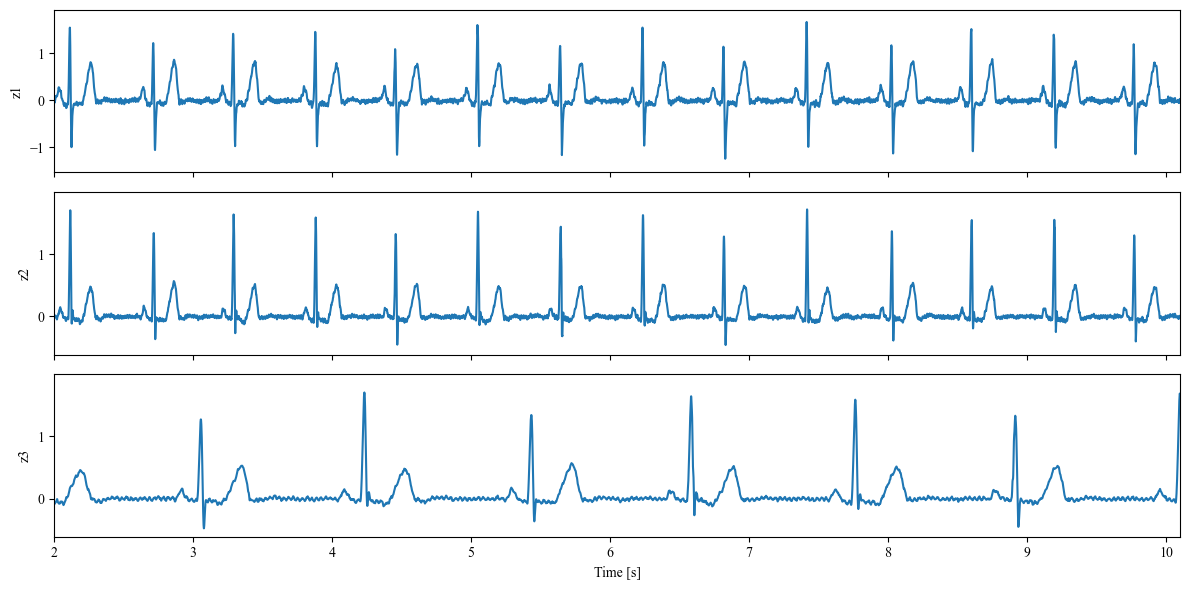

In [866]:
fig, axs = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
axs[0].plot(t,fECGrs1[sig_range])
axs[0].set_ylabel('z1')
axs[1].plot(t,fECGrs2[sig_range])
axs[1].set_ylabel('z2')
axs[2].plot(t,mECGrs[sig_range])
axs[2].set_ylabel('z3')
axs[2].set_xlabel('Time [s]')
axs[0].set_xlim([2, 10.1])
plt.tight_layout()
plt.show()



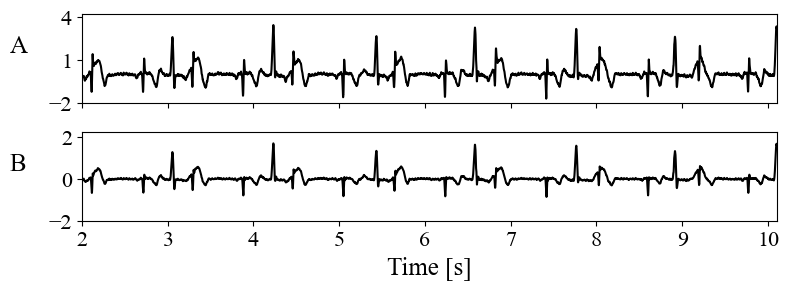

In [867]:
fig, axs = plt.subplots(2, 1, figsize=(8, 3), sharex=True)

axs[0].plot(t, sig1, 'k')
axs[0].set_ylabel('A   ', fontsize=18, rotation=0, labelpad=15)

axs[1].plot(t, sig2, 'k')
axs[1].set_ylabel('B   ', fontsize=18, rotation=0, labelpad=15)
axs[1].set_xlabel('Time [s]', fontsize=18)

axs[0].set_xlim([2, 10.1])
axs[1].set_xlim([2, 10.1])
axs[0].set_ylim([-2,4.2])
axs[1].set_ylim([-1.25,2.25])
axs[0].set_yticks(np.arange(-2, 4.5, 3))
axs[1].set_yticks(np.arange(-2, 2.5, 2))




# --- Tick label sizes for both subplots ---
for ax in axs:
    ax.tick_params(axis='both', labelsize=16)

plt.tight_layout()
plt.savefig("ecg_AB.pdf")
plt.show()


In [868]:
sig1 = preprocess_ecg(sig1)
sig2 = preprocess_ecg(sig2)

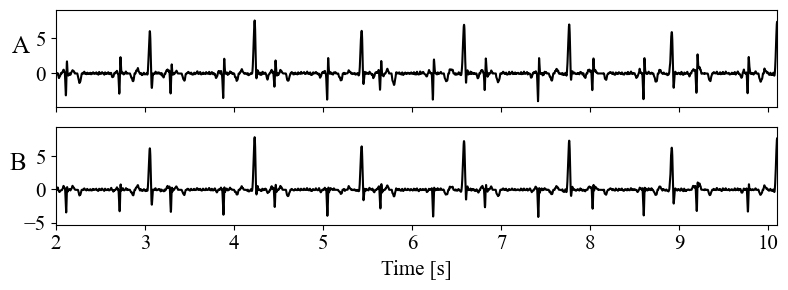

In [869]:
# Plot simulated signals (Figure 4)

fig, axs = plt.subplots(2, 1, figsize=(8, 3), sharex=True)
axs[0].plot(t, sig1, 'k')
axs[0].set_ylabel('A   ', fontsize=18, rotation=0)
axs[1].plot(t, sig2, 'k')
axs[1].set_ylabel('B', fontsize=18, rotation=0)
axs[1].set_xlabel('Time [s]', fontsize=15)
axs[0].set_xlim([2, 10.1])
axs[0].tick_params(axis='both', labelsize=15)
axs[1].tick_params(axis='both', labelsize=15)


plt.tight_layout()
# plt.savefig("ecg_AB.pdf")
plt.show()

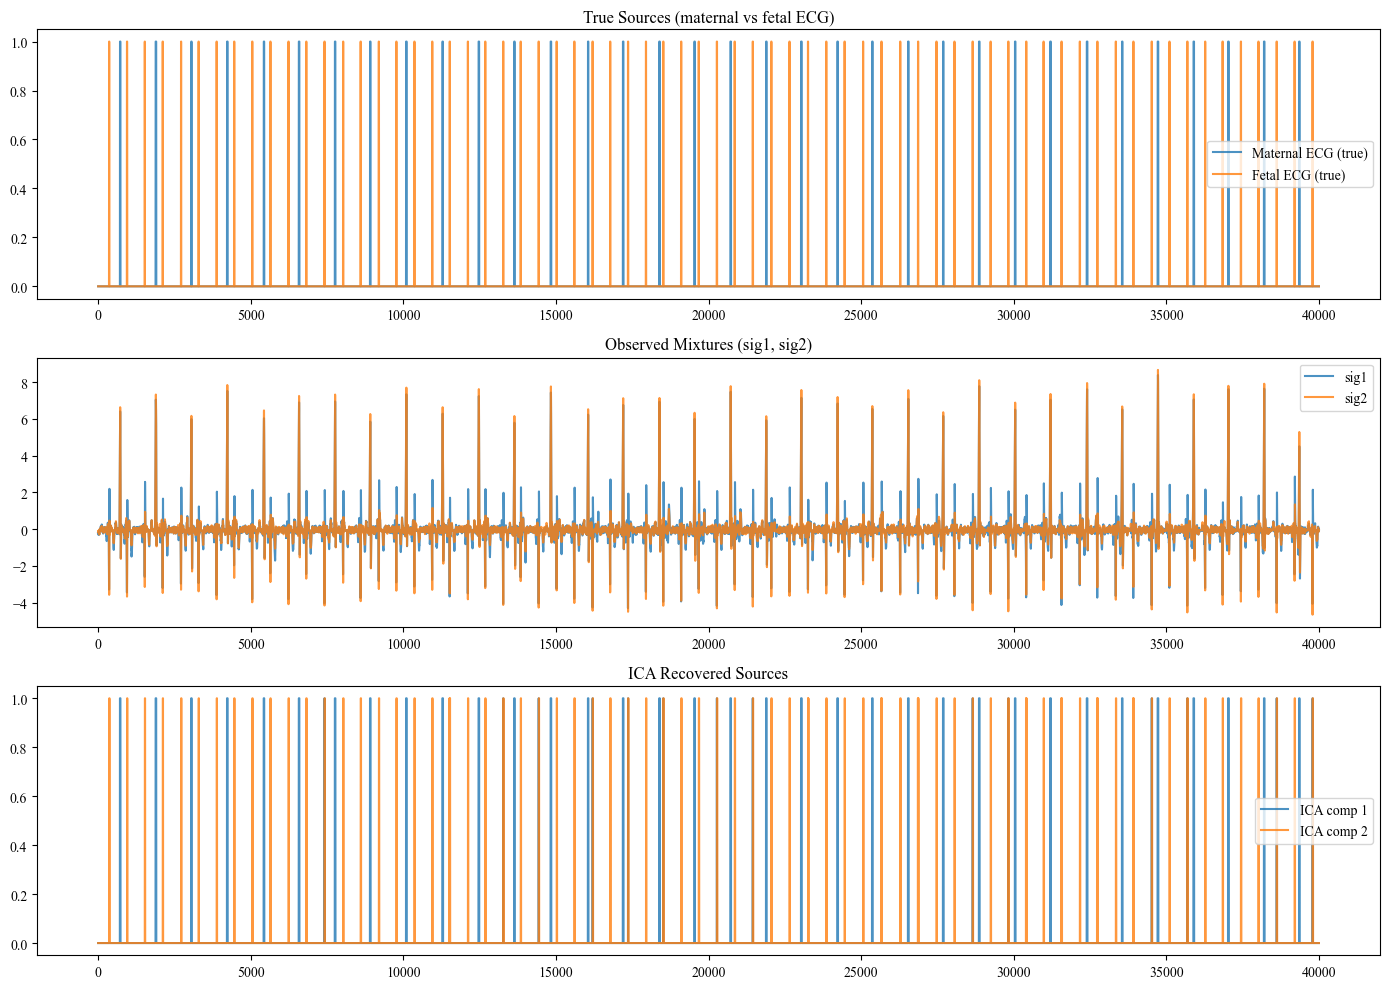

In [870]:
# -------------------------
# 0) prepare mixtures
# -------------------------
# assume sig1, sig2 are numpy arrays length len_sig and fs == 1000
M = np.column_stack([sig1, sig2])   # shape (len_sig, 2)

# 1) standardize channels (zero mean, unit var)
M_std = (M - M.mean(axis=0)) / (M.std(axis=0) + 1e-12)


# 2) run FastICA (2 components)
ica = FastICA(n_components=2, random_state=0, max_iter=2000)
S_est = ica.fit_transform(M)   # shape (len_sig, 2)
S_est_norm = normalize(S_est.T).T
A_est = ica.mixing_

f_true = (fECGrs2[sig_range]) >1  # fetal
m_true = (mECGrs[sig_range]) >1   # maternal
f_true_single = collapse_windows_to_centers(f_true, mode="center")

# Plot results
plt.figure(figsize=(14,10))

plt.subplot(3,1,1)
plt.title("True Sources (maternal vs fetal ECG)")
plt.plot(m_true, label="Maternal ECG (true)", alpha=0.8)
plt.plot(f_true, label="Fetal ECG (true)", alpha=0.8)
plt.legend()

plt.subplot(3,1,2)
plt.title("Observed Mixtures (sig1, sig2)")
plt.plot((sig1), label="sig1", alpha=0.8)
plt.plot((sig2), label="sig2", alpha=0.8)
plt.legend()

plt.subplot(3,1,3)
plt.title("ICA Recovered Sources")
plt.plot(np.abs(S_est_norm[:,0])>0.02, label="ICA comp 1", alpha=0.8)
plt.plot(np.abs(S_est_norm[:,1])>0.02, label="ICA comp 2", alpha=0.8)
plt.legend()

plt.tight_layout()
plt.show()


In [871]:

prec_ICA1, rec_ICA1, pr_auc_ICA1 = coverage_PR_AUC(S_est[:, 0], f_true_single, fs, thresholds=None, tolerance_window=50)
prec_ICA2, rec_ICA2, pr_auc_ICA2 = coverage_PR_AUC(S_est[:, 1], f_true_single, fs, thresholds=None, tolerance_window=50)

print(pr_auc_ICA1)
print(pr_auc_ICA2)


0.06147492787196479
0.9852941176470589


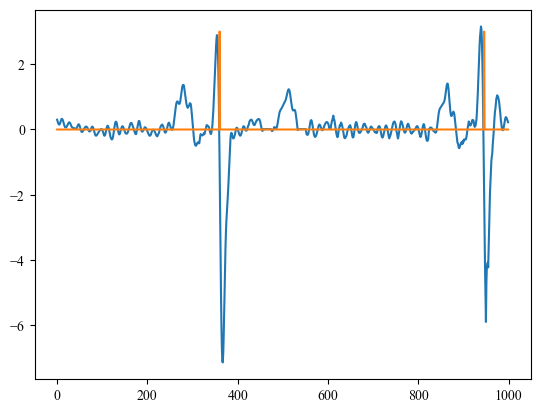

In [872]:
# plt.plot(S_est[:, 0][:1000])
plt.plot(S_est[:, 1][:1000])

plt.plot(f_true_single[:1000]*3)


In [15]:
v_ica_raw = np.abs(S_est[:, 0]) > np.median(np.abs(S_est[:, 0])) + 2.5 * np.std(np.abs(S_est[:, 0]))
v_ica_up1 = np.where(v_ica_raw)[0]

v_ica_raw2 = np.abs(S_est[:, 1]) > np.median(np.abs(S_est[:, 1])) + 2.5 * np.std(np.abs(S_est[:, 1]))
v_ica_up2 = np.where(v_ica_raw2)[0]

In [479]:


def const_lag(sig, lag, jump):
    N = len(sig)
    # Build lagged matrix like MATLAB lagmatrix
    lags = np.column_stack([np.roll(sig, -k) for k in range(lag+1)])
    # Trim the last lag rows that wrapped around
    lags = lags[:N-lag, :]
    # Subsample rows with step = jump
    lags = lags[::jump, :]
    
    return lags
    
def const_lags(sig, win_size=12, step=6):
    windows = sliding_window_view(sig, win_size)
    return windows[::step]
    
lag = 8
jump = 7

siglag1 = const_lags(sig1, lag, jump)
siglag2 = const_lags(sig2, lag, jump)

# # Reference data lagmaps:
fECGlag = const_lag(fECGrs2[sig_range], lag, jump ) 
# # fECG values at points that will correspond to the eigenvector points of 
# # the diffusion maps operators and operators A and S
f_true_lag = (np.max(fECGlag,axis=1)>1)#fECGlag[:,0] >1

mECGlag = const_lag( mECGrs[sig_range], lag, jump )
# # fECG values at points that will correspond to the eigenvector points of 
# # the diffusion maps operators and operators A and S


f_true_lag_single = collapse_windows_to_centers(f_true_lag, mode="center")


In [325]:
# kernels

def diffusion_map(X, adaptive=5500):
    if adaptive is not None:
        K = Kernel_matrix(X, adaptive)
    else:
        # Pairwise Euclidean distances
        pairwise_dists = squareform(pdist(X, metric='euclidean'))
        # Kernel scale ε = median of distances (common practice)
        epsilon = np.median(pairwise_dists)
        # Construct affinity matrix using squared distance
        K = np.exp(- (pairwise_dists ** 2) / (epsilon ** 2))
    D_inv = np.diag(1.0 / np.sum(K, axis=1))
    P = D_inv @ K
    Q = K @ D_inv
    # eigvals, eigvecs = eig(P)
    # idx = np.argsort(eigvals)[::-1]
    #eigvecs[:, idx], eigvals[idx]
    return P, Q, K
    
P1, Q1, K1 = diffusion_map(siglag1, 4000) #4500
P2, Q2, K2 = diffusion_map(siglag2, 4000)

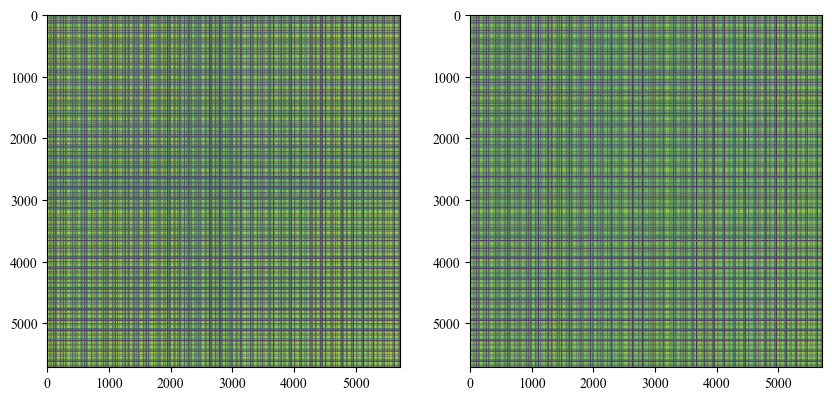

In [326]:
fig, ax = plt.subplots(1,2,figsize=(10,5))

ax[0].imshow(K1)
ax[1].imshow(K2)


# SHNITZER ET AL

In [327]:
# Cell 6: Construct S and A operators and eigenvectors
S = P2 @ Q1 + P1 @ Q2
A = P2 @ Q1 - P1 @ Q2

# Use eigh for symmetric matrices
ES_vals, VS = eig(S)
VS = VS[:, np.argsort(ES_vals)[::-1]]

EA_vals, VA = eig(A)

VA_imag = np.imag(VA[:, np.argsort(np.imag(EA_vals))[::-1]])
VA_real = np.real(VA[:, np.argsort(np.real(EA_vals))[::-1]])



In [773]:
prec_imag,rec_imag, pr_auc_imag = coverage_PR_AUC(VA_imag[:, 0], f_true_lag_single, fs, thresholds=None, tolerance_window=7)
prec_real,rec_real, pr_auc_real = coverage_PR_AUC(VA_real[:, 0], f_true_lag_single, fs, thresholds=None, tolerance_window=7)

print(pr_auc_imag)
print(pr_auc_real)


0.16741987013347537
0.9172206132530201


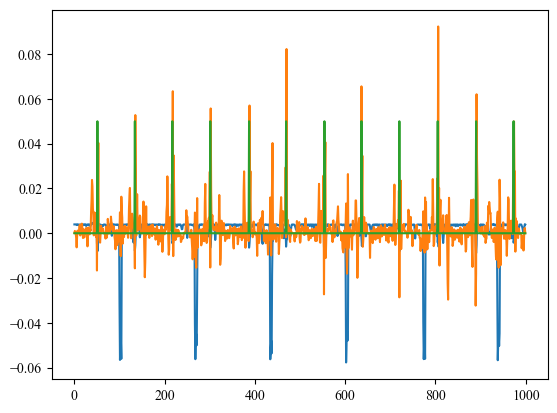

In [611]:

plt.plot(VA_imag[:, 0][:1000])
plt.plot(VA_real[:, 0][:1000])

plt.plot(f_true_lag_single[:1000]*0.05)


In [23]:
med_sh = np.median(np.c_[VA_imag[:,:5],VA_real[:,:5]],axis=1)        
v_sh = med_sh>np.median(med_sh)+5* np.std(med_sh)
v_sh_up = subsampled_row_to_orig_sample(np.where(v_sh)[0])


# DELVE

In [330]:

L1, d1, v1 = LG_sym(K1)
L2, d2, v2 = LG_sym(K2)


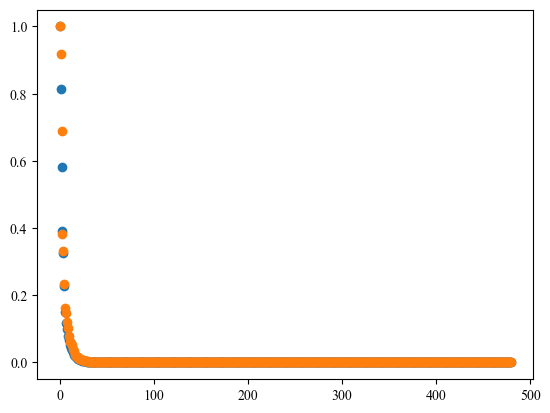

In [331]:
plt.scatter(np.arange(480),d1[:480])
plt.scatter(np.arange(480),d2[:480])


In [384]:
s1, u1 = calc_differential_vec(L2,v1,4) #3

s2, u2 = calc_differential_vec(L1,v2,4)


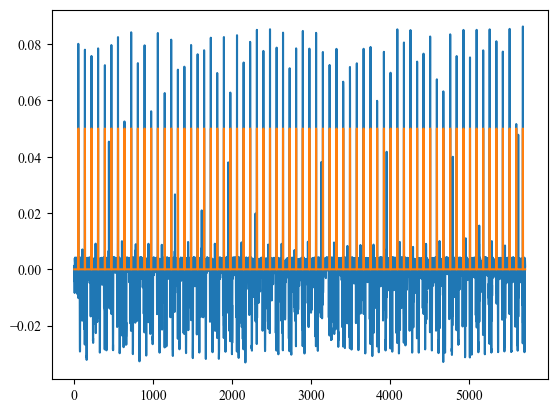

In [386]:

plt.plot(u1[:,0])
plt.plot(f_true_lag*0.05)


In [758]:
if np.corrcoef(u2[:,0], f_true_lag_single)[0,1] < 0:
    print("-")
else:
    print(np.corrcoef(u2[:,0], f_true_lag_single)[0,1])
    

0.16572761109978018


In [774]:
prec_u1,rec_u1, pr_auc_u1 =coverage_PR_AUC(u1[:,0], f_true_lag_single, 1, thresholds=None, tolerance_window=7)
prec_u2,rec_u2, pr_auc_u2 =coverage_PR_AUC(u2[:,0], f_true_lag_single, 1, thresholds=None, tolerance_window=7)

print(pr_auc_u1)
print(pr_auc_u2)


0.9850461837627612
0.9559189023452993


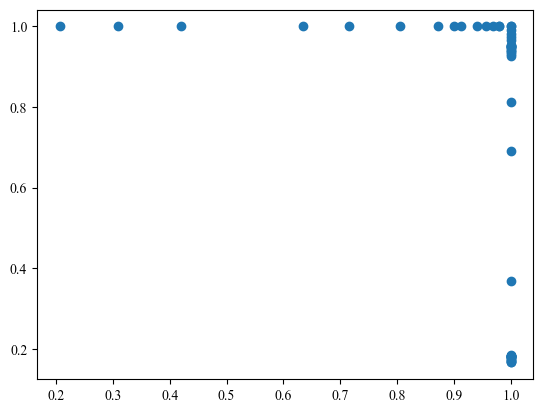

In [739]:
idx_u1 = np.argsort(rec_u1)
plt.scatter(rec_u1[idx_u1],prec_u1[idx_u1])


In [775]:
prec_u1s,rec_u1s, pr_auc_u1s =coverage_PR_AUC(sparse_u1, f_true_single, 1, thresholds=None, tolerance_window=50)
prec_u2s,rec_u2s, pr_auc_u2s =coverage_PR_AUC(sparse_u2, f_true_single, 1, thresholds=None, tolerance_window=50)

print(pr_auc_u1s)
print(pr_auc_u2s)

0.9850461837627612
0.9559189023452993


In [31]:
med_dif = np.median(np.c_[u1[:,:5],u2[:,:5]],axis=1)
v_dif = med_dif>np.median(med_dif)+2* np.std(med_dif)
v_dif_up = subsampled_row_to_orig_sample(np.where(v_dif)[0])


# FKT

In [624]:
#FK transform

G1 = np.diag(np.sum(K1, axis=0)) - K1  
G2 = np.diag(np.sum(K2, axis=0)) - K2  

M1 = G1 + 0.0000001 * np.eye(G1.shape[0])
M2 = G2 + 0.0000001 * np.eye(G2.shape[0])

eval_G1, evec_G1 = np.linalg.eig(M1)
eval_G2, evec_G2 = np.linalg.eig(M2)

FK1 = np.linalg.inv(M1+M2)@M1
FK2 = np.linalg.inv(M1+M2)@M2

FK_values_1, eig_vec_FK_1 = eig(FK1)
FK_values_2, eig_vec_FK_2 = eig(FK2)

idx_1 = np.argsort(FK_values_1)[::-1]
eig_vec_FK_1 = eig_vec_FK_1[:,idx_1]

idx_2 = np.argsort(FK_values_2)[::-1]
eig_vec_FK_2 = eig_vec_FK_2[:,idx_2]



In [776]:
prec_fkt1,rec_fkt1, pr_auc_fkt1 =coverage_PR_AUC(np.real(eig_vec_FK_1[:, 0]), f_true_lag_single, 1, thresholds=None, tolerance_window=7)
prec_fkt2,rec_fkt2, pr_auc_fkt2 =coverage_PR_AUC(np.real(eig_vec_FK_2[:, 0]), f_true_lag_single, 1, thresholds=None, tolerance_window=7)

print(pr_auc_fkt1)
print(pr_auc_fkt2)


0.15919738178689397
0.6457254986396891


In [37]:
med_fkt = np.median(np.c_[eig_vec_FK_1[:,:5],eig_vec_FK_2[:,:5]],axis=1)
v_fkt = med_fkt>np.median(med_fkt)+2* np.std(med_fkt)
v_fkt_up = subsampled_row_to_orig_sample(np.where(v_fkt)[0])


In [829]:
methods_detections = {
            'DELVE A': u1[:,0],
            'DELVE B': u2[:,0],
            'Shintzer (real)': VA_real[:, 0],
            'Shintzer (imag)': VA_imag[:, 0],
            'FKT A': np.real(eig_vec_FK_1[:, 0]),
            'FKT B': np.real(eig_vec_FK_2[:, 0]),
            'ICA #1': S_est[:,0],
            'ICA #2': S_est[:,1]
        }

window_sizes = [0, 10, 25, 50]
rows = []

for w in window_sizes:
    for method_name, score in methods_detections.items():
        if method_name[:3]=="ICA":
             _, _, pr_auc = coverage_PR_AUC(
            score_signal=score,
            gt=f_true_single,
            fs=1,
            thresholds=None,
            tolerance_window=w*7+1,
            )
        else: 
            _, _, pr_auc = coverage_PR_AUC(
                score_signal=window_vector_to_signal(score, len(sig1), lag, jump, fill_value=0.0),
                gt=f_true_single,
                fs=1,
                thresholds=None,
                tolerance_window=w,
            )

        rows.append({
            "method": method_name,
            "tolerance_window": w,
            "pr_auc": pr_auc,
        })

df = pd.DataFrame(rows)
df["tolerance_window"] = df["tolerance_window"]

table = df.pivot(
    index="tolerance_window",
    columns="method",
    values="pr_auc"
)

print(table)



method             DELVE A   DELVE B     FKT A     FKT B    ICA #1    ICA #2  \
tolerance_window                                                               
0                 0.030538  0.000854  0.012891  0.001992  0.001592  0.037478   
10                0.985046  0.223062  0.157650  0.117692  0.062326  0.985294   
25                0.985046  0.955788  0.158205  0.645725  0.167576  0.985294   
50                0.985046  0.955919  0.159129  0.645725  0.985294  0.985294   

method            Shintzer (imag)  Shintzer (real)  
tolerance_window                                    
0                        0.008686         0.004088  
10                       0.156419         0.657360  
25                       0.158222         0.914066  
50                       0.166044         0.917024  


In [830]:
table.round(3).T.to_latex(
    "synthetic_pr_auc.tex",
    float_format="%.3f"
)
print(np.round(table,3).T)

tolerance_window     0      10     25     50
method                                      
DELVE A           0.031  0.985  0.985  0.985
DELVE B           0.001  0.223  0.956  0.956
FKT A             0.013  0.158  0.158  0.159
FKT B             0.002  0.118  0.646  0.646
ICA #1            0.002  0.062  0.168  0.985
ICA #2            0.037  0.985  0.985  0.985
Shintzer (imag)   0.009  0.156  0.158  0.166
Shintzer (real)   0.004  0.657  0.914  0.917


In [826]:
table.round(3).T.to_latex(
    "synthetic_pr_auc.tex",
    float_format="%.3f"
)
print(np.round(table,3).T)

tolerance_window     0      7      21     49
method                                      
DELVE A           0.431  0.985  0.985  0.985
DELVE B           0.006  0.067  0.956  0.956
FKT A             0.121  0.158  0.158  0.159
FKT B             0.033  0.095  0.646  0.646
ICA #1            0.002  0.002  0.053  0.061
ICA #2            0.037  0.955  0.985  0.985
Shintzer (imag)   0.113  0.156  0.160  0.167
Shintzer (real)   0.025  0.673  0.915  0.917


In [803]:
def lighten_color(color, amount=0.5):
    """
    amount=0 -> original color
    amount=1 -> white
    """
    rgb = np.array(mcolors.to_rgb(color))
    return tuple(rgb + (1 - rgb) * amount)

COLOR_FAMILIES = {
    "DELVE": "tab:blue",
    "Shnitzer": "tab:red",
    "FKT": "tab:green",
    "ICA": "tab:purple",
}

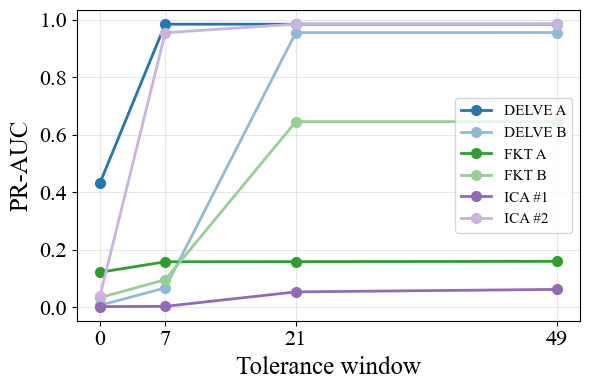

In [820]:
import matplotlib.colors as mcolors

plt.figure(figsize=(6, 4))

for family, base_color in COLOR_FAMILIES.items():

    sub_family = df[df["method"].str.startswith(family)]
    if sub_family.empty:
        continue

    detailed_methods = sub_family["method"].unique()
    shades = np.linspace(0.0, 0.5, len(detailed_methods))

    for method_name, shade in zip(detailed_methods, shades):

        sub = df[df["method"] == method_name]
        color = lighten_color(base_color, shade)

        plt.plot(
            sub["tolerance_window"] * 7,
            sub["pr_auc"],
            marker="o",
            linewidth=2.0,
            markersize=7,
            color=color,
            label=method_name
        )

# ---- ticks ----
tol_vals = np.sort(df["tolerance_window"].unique())
plt.xticks(tol_vals * 7, tol_vals * 7)

plt.tick_params(axis='both', labelsize=16)

plt.xlabel("Tolerance window", fontsize=18)
plt.ylabel("PR-AUC", fontsize=18)

plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("ECG_synthetic_results-PRAUC.pdf")
plt.show()


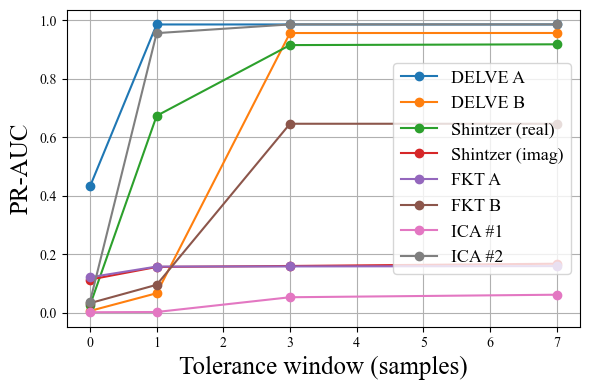

In [802]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

for method_name in methods_detections.keys():
    sub = df[df["method"] == method_name]
    plt.plot(
        sub["tolerance_window"],
        sub["pr_auc"],
        marker="o",
        label=method_name
    )

plt.xlabel("Tolerance window (samples)", fontsize=18)
plt.ylabel("PR-AUC", fontsize=18)
# plt.title("Coverage PR-AUC vs Tolerance Window")
plt.legend(fontsize=13, )
plt.grid(True)
plt.tight_layout()
plt.show()


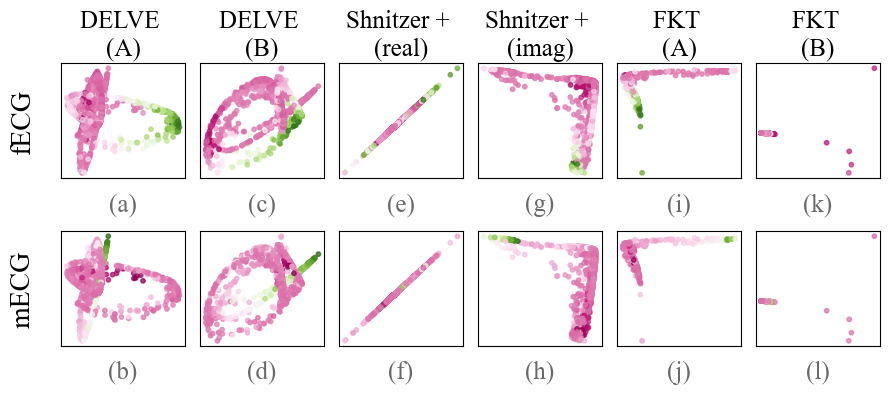

In [788]:

labels_top = ["(a)",  "(c)", "(e)","(g)", "(i)", "(k)"]
labels_bottom = ["(b)", "(d)", "(f)", "(h)","(j)", "(l)"]

       

# Parameters
s_ = 10
titles = [
    "DELVE \n(A)",
    "DELVE \n(B)",
    "Shnitzer + \n(real)",
    "Shnitzer + \n(imag)",
    "FKT \n(A)",
    "FKT \n(B)"
]

# One list only
X_list = [u1, u2, VA_real, VA_imag, np.real(eig_vec_FK_1), np.real(eig_vec_FK_2)]

# Colors
C_top = fECGlag[:, 3]
C_bottom = mECGlag[:, 3]
cmap = plt.cm.PiYG

# Figure setup
fig, ax = plt.subplots(2, 6, figsize=(9, 4.5))
plt.subplots_adjust(wspace=0.25, hspace=0.25)

for i, X in enumerate(X_list):
    # Select proper components per matrix
    if i < 2:  # u1, u2
        x_axis, y_axis = (X[:, 0]), (X[:, 1])
    else:       # VA and FK
        x_axis, y_axis = (X[:, 0]), (X[:, 1])
    
    # Top row (fECG)
    sc1 = ax[0, i].scatter(
        x_axis, y_axis,
        c=C_top,
        cmap=cmap,
        alpha=0.75,
        s=s_,
        rasterized=True
    )
    ax[0, i].set_title(titles[i], fontsize=18)
    ax[0, i].tick_params(labelsize=12)
        # remove ticks
    ax[0, i].set_xticks([])
    ax[0, i].set_yticks([])
    # add subplot label

    # Add panel label under each subplot
    ax[0, i].set_xlabel(labels_top[i], fontsize=18, labelpad=10, c='dimgray')

    # Bottom row (mECG)
    sc2 = ax[1, i].scatter(
        x_axis, y_axis,
        c=C_bottom,
        cmap=cmap,
        alpha=0.75,
        s=s_,
        rasterized=True
    )
    ax[1, i].tick_params(labelsize=12)
    # remove ticks
    ax[1, i].set_xticks([])
    ax[1, i].set_yticks([])


    # Add panel label under each subplot
    ax[1, i].set_xlabel(labels_bottom[i], fontsize=18, labelpad=10, c='dimgray')

# Row titles
ax[0, 0].set_ylabel("fECG", fontsize=20, labelpad=18)
ax[1, 0].set_ylabel("mECG", fontsize=20, labelpad=18)

# Shared colorbar
# cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.02])
# cbar = fig.colorbar(sc2, cax=cbar_ax, orientation='horizontal')
# cbar.set_label("Lagged ECG signal", fontsize=16)
# cbar.ax.tick_params(labelsize=12)

plt.tight_layout(rect=[0, 0.1, 1, 1])  # leave room for colorbar
plt.savefig("Comparative_scatter_plots_fixed.pdf", dpi=100)
plt.show()


In [231]:
final_df_base.round(3).to_latex("final_table_tol50_base.tex", 
                           index=True,
                           caption=f"Results at tolerance = {final_tol} ms",
                           label="tab:results_synthetic_ecg_tol50",
                           float_format="%.3f")

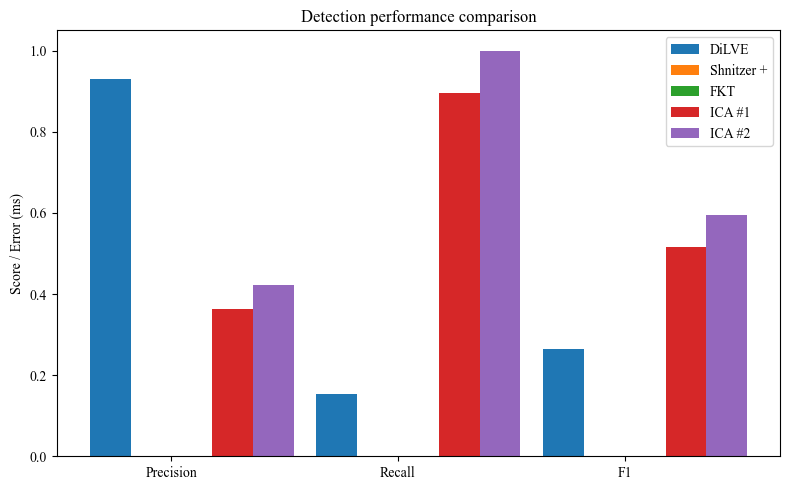

,TP,FP,FN,precision,recall,f1,balanced_accuracy,RMSD,mean_abs_error_ms
DiLVE,94.0,7.0,519.0,0.931,0.153,0.263,0.577,4.750,5.426
Shnitzer +,0.0,0.0,613.0,0.000,0.000,0.000,0.500,NaN,NaN
FKT,0.0,188.0,613.0,0.000,0.000,0.000,0.498,NaN,NaN
ICA #1,549.0,963.0,64.0,0.363,0.896,0.517,0.936,0.481,0.612
ICA #2,613.0,839.0,0.0,0.422,1.000,0.594,0.989,2.370,4.313


In [266]:

detections = {
            'DiLVE': v_dif_up,
            'Shnitzer +': v_sh_up,
            'FKT': v_fkt_up,
            'ICA #1': v_ica_up1,
            'ICA #2': v_ica_up2
        }

# Evaluate all
results = {name: evaluate_detections(det, f_qrs, fs=1000, tol_ms=50)
            for name, det in detections.items()}

# ===== Plot results =====
metrics = ['precision', 'recall', 'f1']
x = np.arange(len(metrics))
width = 0.18

plt.figure(figsize=(8, 5))
for i, (name, res) in enumerate(results.items()):
    values = [res[m] for m in metrics]
    plt.bar(x + i*width, values, width, label=name)

plt.xticks(x + width*1.5, ['Precision', 'Recall', 'F1'])
plt.ylabel("Score / Error (ms)")
plt.title("Detection performance comparison")
plt.legend()
plt.tight_layout()
plt.show()

# ===== Optional: print results table =====
import pandas as pd
df = pd.DataFrame(results).T
display(df.round(3))

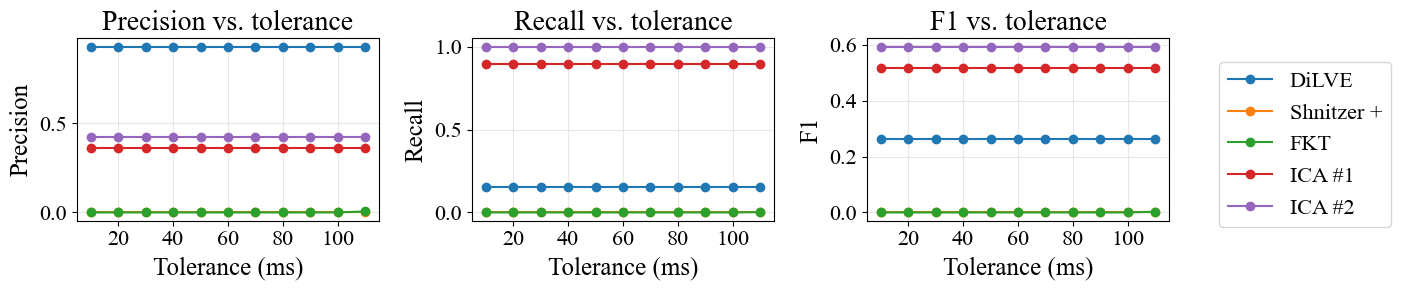

Results at tolerance = 50 ms:


,precision,recall,f1
DiLVE,0.931,0.153,0.263
Shnitzer +,0.000,0.000,0.000
FKT,0.000,0.000,0.000
ICA #1,0.363,0.896,0.517
ICA #2,0.422,1.000,0.594


In [267]:
# Range of tolerances to test (ms)
tolerances = np.arange(10, 120, 10)  # e.g. 10, 50, 90, ..., 290 ms

# Initialize results storage
metrics = ['precision', 'recall', 'f1']
results_vs_tol = {m: {k: [] for k in detections.keys()} for m in metrics}

# Sweep over tolerance values
for tol in tolerances:
    for name, det in detections.items():
        res = evaluate_detections(det, f_qrs, fs=1000, tol_ms=tol)
        for m in metrics:
            results_vs_tol[m][name].append(res[m])

# ---- Plot results ----
plt.figure(figsize=(12, 3))
for m in metrics:
    plt.subplot(1, 3, metrics.index(m) + 1)
    for name in detections.keys():
        plt.plot(tolerances, results_vs_tol[m][name], marker='o', label=name)
    plt.title(m.capitalize() + " vs. tolerance", fontsize=20)
    plt.xlabel("Tolerance (ms)", fontsize=18)
    plt.ylabel(m.capitalize(), fontsize=18)
    plt.grid(True, alpha=0.3)
    plt.tick_params(axis='both', labelsize=16)
    plt.locator_params(axis='x', nbins=6)


# Create a single shared legend outside the plots
# (get handles/labels from the last axis)
handles, labels = plt.gca().get_legend_handles_labels()
plt.figlegend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5),fontsize=16)
plt.tight_layout()  # leave space on right for legend
plt.savefig("ECG simulated results.pdf", bbox_inches="tight", pad_inches=0.2)
plt.show()

# ---- Optional: tabular summary at largest tolerance ----
final_tol = tolerances[4]
final_df = pd.DataFrame({name: {m: results_vs_tol[m][name][4] for m in metrics}
                         for name in detections.keys()}).T
print(f"Results at tolerance = {final_tol} ms:")
display(final_df.round(3))

In [261]:
final_df.round(3).to_latex("final_table_tol50.tex", 
                           index=True,
                           caption=f"Results at tolerance = {final_tol} ms",
                           label="tab:results_synthetic_ecg_tol50",
                           float_format="%.3f")

In [262]:

# ---- Optional: tabular summary at largest tolerance ----
final_tol = tolerances[4]
final_df_comb = pd.DataFrame({name: {m: results_vs_tol[m][name][4] for m in metrics}
                         for name in detections.keys()}).T
print(f"Results at tolerance = {final_tol} ms:")
display(final_df.round(3))

Results at tolerance = 50 ms:


,precision,recall,f1
DiLVE,0.931,0.153,0.263
Shnitzer +,0.000,0.000,0.000
FKT,0.000,0.000,0.000
ICA #1,0.363,0.896,0.517
ICA #2,0.422,1.000,0.594
